In [1]:
pip install tqdm


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, random, shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from PIL import Image

In [3]:
BASE_DIR      = Path(r"D:\Sem3\Projek ML\Progres 1\Data set")
RICE_LABELLED = BASE_DIR / "LabelledRice" / "Labelled"
RICE_DISEASE  = BASE_DIR / "RiceDiseaseDataset"
SUBSET_DIR    = BASE_DIR / "dataset_subset"

#parameter
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
N_PER_CLASS  = 800
SEED         = 42
IMG_EXT      = "*.jpg"


 Distribusi kelas di tiap dataset

In [4]:
def count_classes(root: Path) -> dict:
    result = {}
    for cls_dir in sorted(root.iterdir()):
        if cls_dir.is_dir():
            result[cls_dir.name] = len(list(cls_dir.glob(IMG_EXT)))
    return result
dist_labelled    = count_classes(RICE_LABELLED)
dist_train       = count_classes(RICE_DISEASE / "train")
dist_val         = count_classes(RICE_DISEASE / "validation")
df_dist = pd.DataFrame({
    "LabelledRice"           : dist_labelled,
    "RiceDiseaseDataset/train": dist_train,
    "RiceDiseaseDataset/val"  : dist_val,
}).fillna(0).astype(int)

df_dist.loc["TOTAL"] = df_dist.sum()
print(df_dist.to_string())

           LabelledRice  RiceDiseaseDataset/train  RiceDiseaseDataset/val
BrownSpot           523                       400                     123
Healthy            1488                       400                     123
Hispa               565                       400                     123
LeafBlast           779                       400                     123
TOTAL              3355                      1600                     492


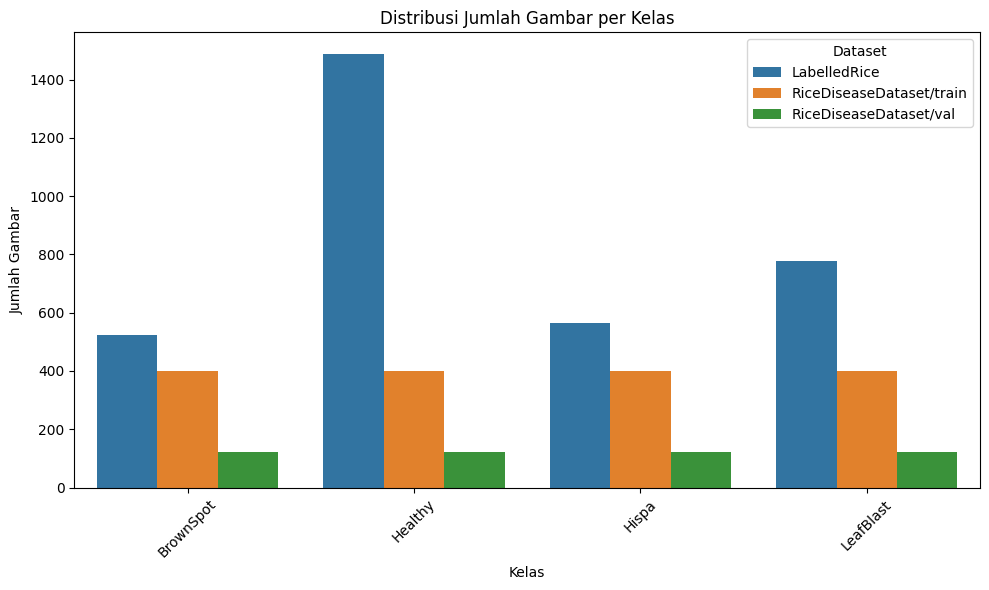

In [5]:
df_plot = df_dist.drop(index="TOTAL").reset_index().melt(
    id_vars="index", var_name="Dataset", value_name="Count"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x="index", y="Count", hue="Dataset")
plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=45)
plt.tight_layout()

Visualisasi sampel gambar tiap kelas

In [6]:
def show_samples(root: Path, title: str, n_sample: int = 3):
    classes = sorted([d.name for d in root.iterdir() if d.is_dir()])
    n_classes = len(classes)

    fig, axes = plt.subplots(n_classes, n_sample, 
                             figsize=(n_sample * 3.5, n_classes * 3.2))
    fig.suptitle(title, fontsize=14, fontweight="bold")
    for r, cls in enumerate(classes):
        imgs = list((root / cls).glob("*.jpg")) 
        
        random.seed(42)
        samples = random.sample(imgs, min(n_sample, len(imgs)))
        for c, img_path in enumerate(samples):
            ax = axes[r][c] if n_classes > 1 else axes[c]
            
            # Membaca matriks RGB dan menyamakan dimensi ke 224x224
            img = Image.open(img_path).resize((224, 224))
            ax.imshow(img)
            ax.set_title(cls if c == 0 else "", fontsize=11, 
                         fontweight="bold", loc="left")
            ax.axis("off") 
            
    plt.tight_layout()
    plt.show()

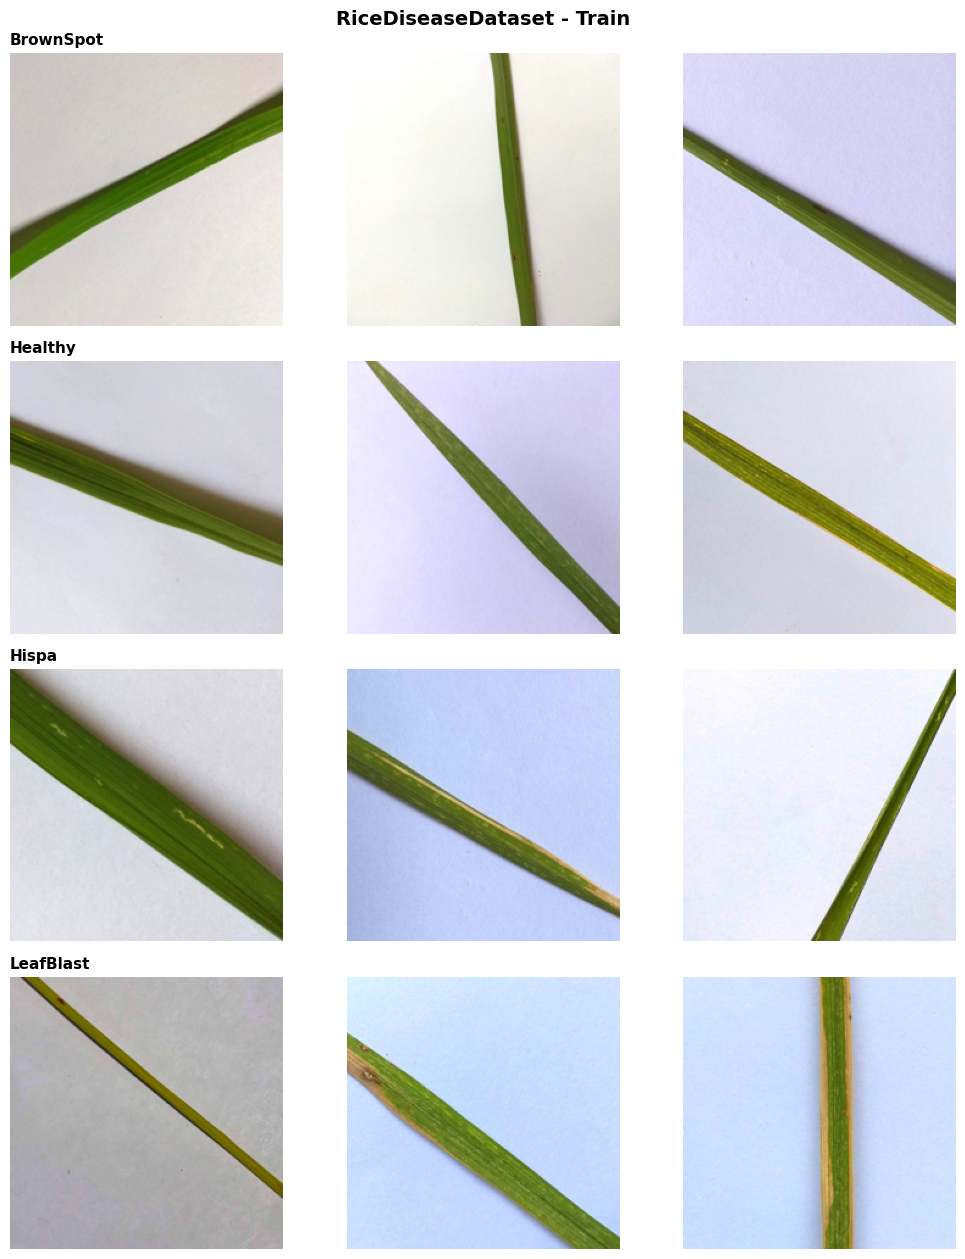

In [7]:
show_samples(RICE_DISEASE / "train", "RiceDiseaseDataset - Train")

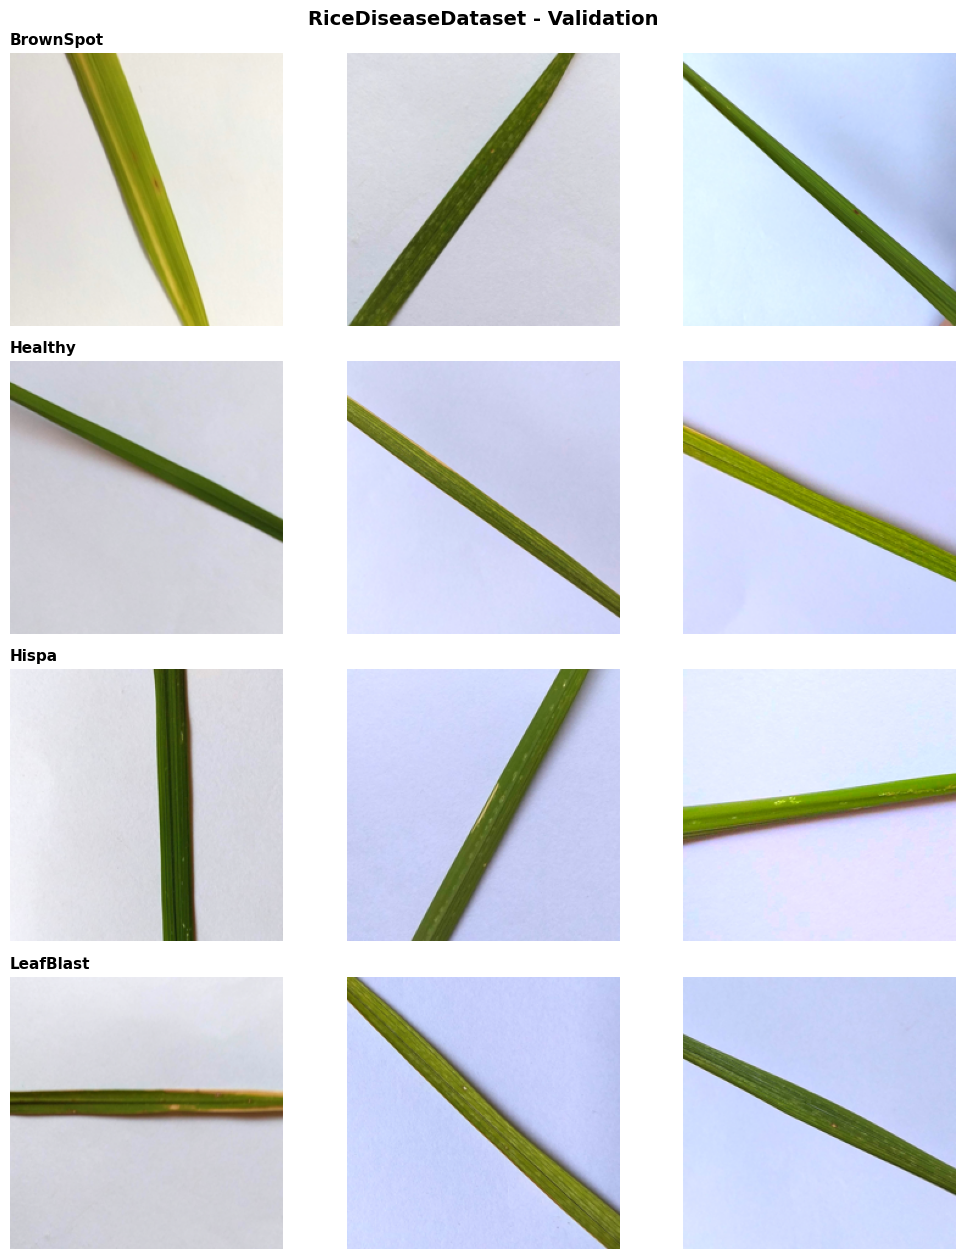

In [8]:
show_samples(RICE_DISEASE / "validation", "RiceDiseaseDataset - Validation")

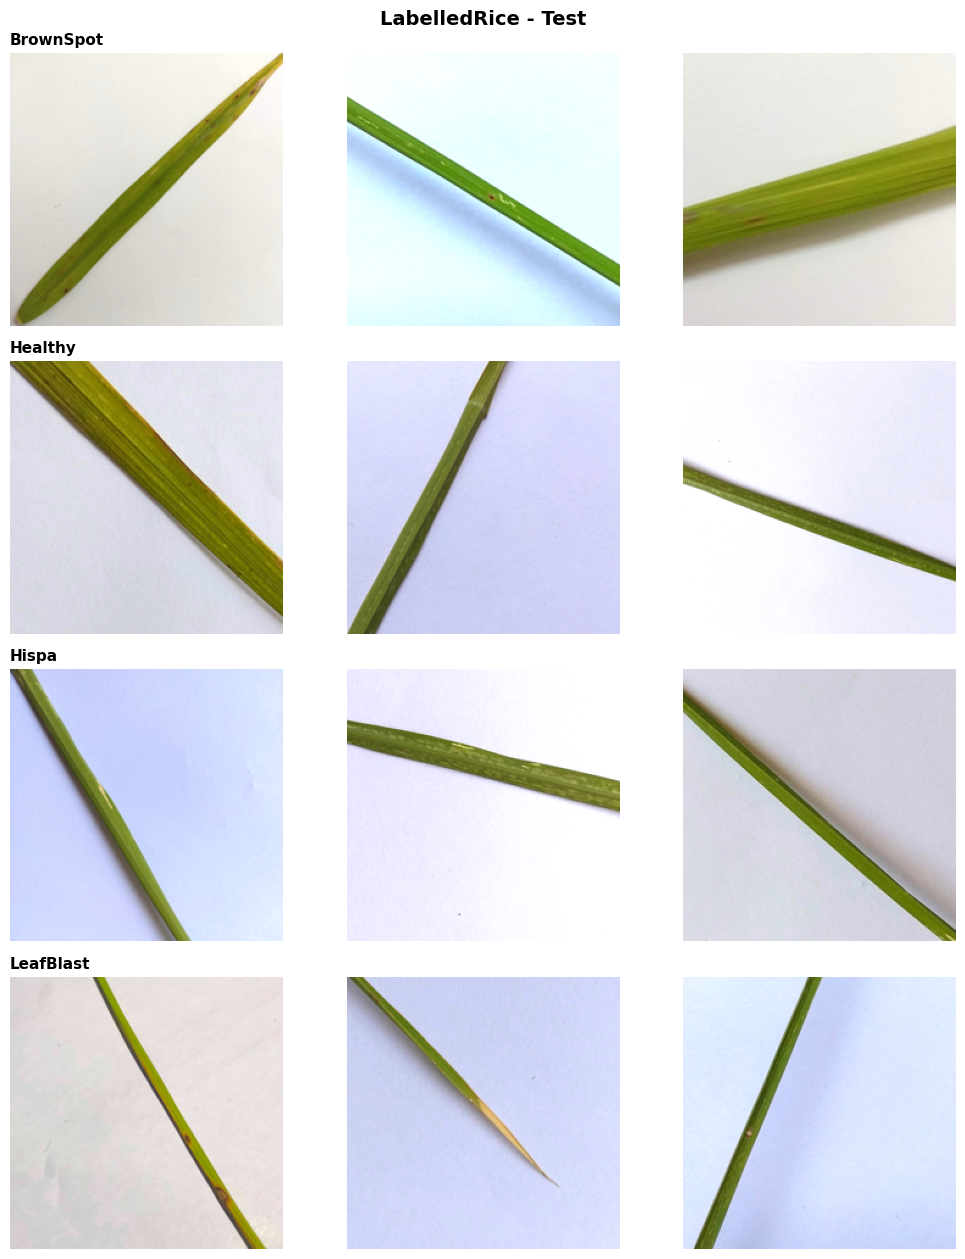

In [9]:
show_samples(RICE_LABELLED, "LabelledRice - Test")

Ukuran & aspek rasio gambar

Statistik ukuran gambar (pixel):
        width  height
count  1600.0  1600.0
mean   2053.0  2053.0
std     620.1   620.1
min     812.0   812.0
25%    1588.0  1588.0
50%    1924.5  1924.5
75%    2389.2  2389.2
max    3120.0  3120.0


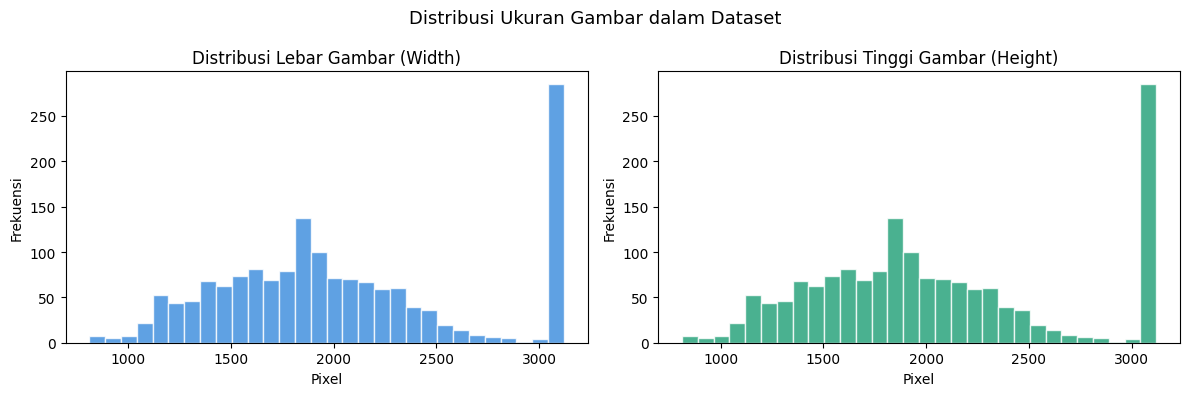

In [10]:
widths, heights, cls_names = [], [], []

sample_root = RICE_DISEASE / "train"
for cls_dir in sorted(sample_root.iterdir()):
    if not cls_dir.is_dir(): continue
    imgs = list(cls_dir.glob(IMG_EXT))[:400]  
    for img_path in imgs:
        with Image.open(img_path) as im:
            w, h = im.size
            widths.append(w); heights.append(h)
            cls_names.append(cls_dir.name)

df_size = pd.DataFrame({"width": widths, "height": heights, "class": cls_names})
print("Statistik ukuran gambar (pixel):")
print(df_size[["width","height"]].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=30, color="#378add", alpha=0.8, edgecolor="white")
axes[0].set_title("Distribusi Lebar Gambar (Width)")
axes[0].set_xlabel("Pixel"); axes[0].set_ylabel("Frekuensi")
axes[1].hist(heights, bins=30, color="#1d9e75", alpha=0.8, edgecolor="white")
axes[1].set_title("Distribusi Tinggi Gambar (Height)")
axes[1].set_xlabel("Pixel"); axes[1].set_ylabel("Frekuensi")
plt.suptitle("Distribusi Ukuran Gambar dalam Dataset", fontsize=13)
plt.tight_layout()
plt.savefig("eda_ukuran_gambar.png", dpi=150, bbox_inches="tight")
plt.show()


Arditektur model

In [ ]:
pip install tensorflow

In [16]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Model


# 1. Membangun kerangka graf komputasi (graf matematis)
_base = MobileNetV3Large(
    weights="imagenet",       # Memuat matriks bobot yang sudah dilatih
    include_top=False,        # Memotong lapisan Dense layer klasifikasi asli (1000 kelas)
    input_shape=(224, 224, 3),# Menerima tensor matriks berukuran 224x224 dengan 3 kanal warna
    pooling="avg"             # Menerapkan perhitungan Global Average Pooling di ujung arsitektur
)

# 2. Membekukan pembaruan turunan gradien (gradient descent)
_base.trainable = False

print(f"Model berhasil dimuat. Bentuk tensor keluaran: {_base.output_shape}")

ModuleNotFoundError: No module named 'tensorflow'